# Monte Carlo convergence testing

Function initialization:

In [14]:
from QMC_option_pricing import european_call_cf, european_call_mc

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

Variable initialization:

Change these values to see how they affect the simulation

In [15]:
S0 = 100      # spot
K = 100       # at-the-money strike
T = 1       # 1 year
r = 0.05      # 5% risk-free rate
sigma = 0.20  # 20% volatility
maxiter = 7
exp = 100
confidence = 0.95

CF_price = european_call_cf(S0,K,T,r,sigma) # Exact value

The following code will generate expected returns using the Monte Carlo european option pricing, to test wether the convergence is $\mathcal{O}(n^{-\frac12})$. A moderate estimate for volatility and interest rate is used. The least squares linear fit for the log-log plot is also shown.

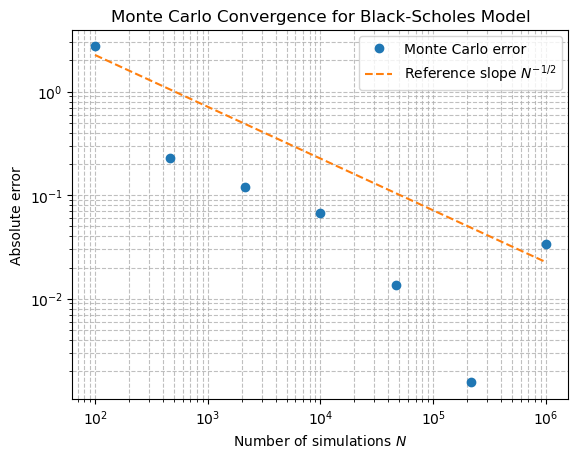

In [16]:
CF_price = european_call_cf(S0,K,T,r,sigma) # Exact value
MC_price = np.zeros(maxiter)
N = np.logspace(2, maxiter-1, maxiter, dtype=int)

for i, n in enumerate(N):
    MC_price[i] = european_call_mc(S0, K, T, r, sigma, n).item()

E = np.abs(MC_price - CF_price)

plt.loglog(N,E,'o',lw=2,label='Monte Carlo error')

# Reference slope O(N^{-1/2})
x = N**(-0.5)
# Least-squares estimate of C
C = np.sum(x * E) / np.sum(x**2)
# Reference line
ref = C * N**(-0.5)

plt.loglog(N,ref,'--',label=r'Reference slope $N^{-1/2}$')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute error')
plt.title('Monte Carlo Convergence for Black-Scholes Model')
plt.legend()
plt.show()

Note how the estimate is really noisy, as the seed choice varies the result heavily. Thus, several simulations with the same parameters can be run, to get more stable estimates. The 95% confidence intervals are also shown.

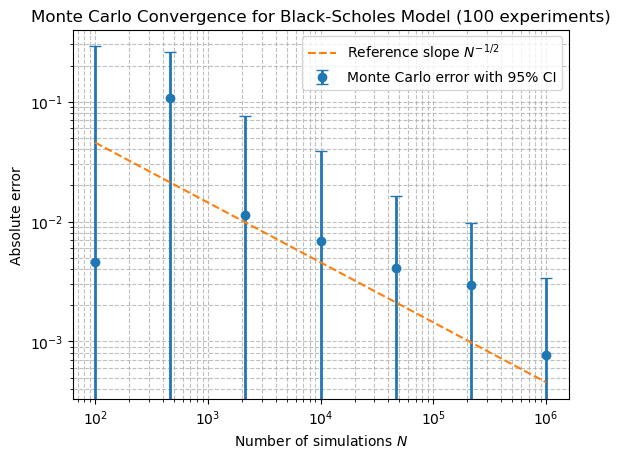

In [17]:
MC_price = np.zeros(maxiter)
CI = np.zeros(maxiter)
N = np.logspace(2, maxiter-1, maxiter, dtype=int)

for i, n in enumerate(N):
    prices = european_call_mc(S0, K, T, r, sigma, n, exp)
    mean = np.mean(prices)
    MC_price[i] = mean

    # CI calculation
    sem = np.std(prices, ddof=1) / np.sqrt(exp)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=exp - 1)
    CI[i] = t_crit * sem

E = np.abs(MC_price - CF_price)

plt.errorbar(N,E,yerr=CI,fmt='o',lw=2,capsize=4,label=f'Monte Carlo error with {100*confidence:.0f}% CI')

# Reference slope O(N^{-1/2})
x = N**(-0.5)
# Least-squares estimate of C
C = np.sum(x * E) / np.sum(x**2)
# Reference line
ref = C * N**(-0.5)

plt.loglog(N,ref,'--',label=r'Reference slope $N^{-1/2}$')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute error')
plt.title(f'Monte Carlo Convergence for Black-Scholes Model ({exp} experiments)')
plt.legend()
plt.show()

Moreover, once the values for various experiments can be retrieved, the defining metrics for the Monte Carlo method, as well as all the improvements that will be made, can be obtained. These metrics are the bias, variance and RMSE. The plot contains $\text{Bias}^2$, variance, RMSE. Note how bias estimates are much more susceptible to Monte Carlo noise, as the difference between two really close magnitudes is being measured.

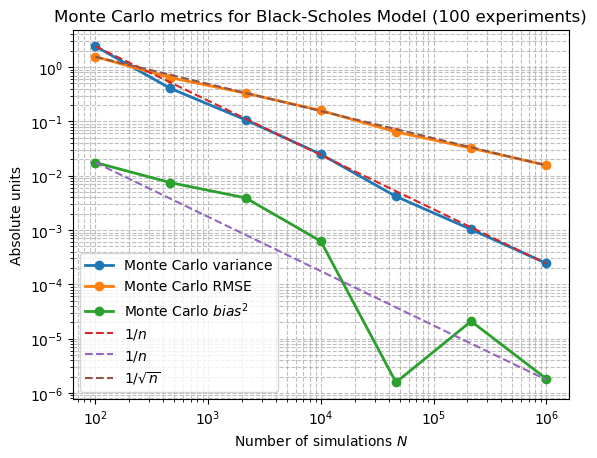

In [18]:
MC_bias = np.zeros(maxiter)
MC_variance = np.zeros(maxiter)
MC_RMSE = np.zeros(maxiter)
N = np.logspace(2, maxiter-1, maxiter, dtype=int)

for i, n in enumerate(N):
    price = european_call_mc(S0, K, T, r, sigma, n, exp)
    MC_bias[i] = np.mean(price) - CF_price
    MC_variance[i] = np.var(price, ddof=1)
    MC_RMSE[i] = np.sqrt(np.mean((price - CF_price)**2))

plt.loglog(N,MC_variance,'o-',lw=2,label='Monte Carlo variance')
plt.loglog(N,MC_RMSE,'o-',lw=2,label='Monte Carlo RMSE')
plt.loglog(N,MC_bias**2,'o-',lw=2,label='Monte Carlo $bias^2$')

ref = 1 / N
plt.loglog(N, ref * MC_variance[0]/ref[0], '--', label='$1/n$')
plt.loglog(N, ref * MC_bias[0]**2/ref[0], '--', label='$1/n$')

ref = 1 / np.sqrt(N)
plt.loglog(N, ref * MC_RMSE[0]/ref[0], '--', label='$1/\sqrt{n}$')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute units')
plt.title(f'Monte Carlo metrics for Black-Scholes Model ({exp} experiments)')
plt.legend()
plt.show()
